In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020.csv


In [ ]:
import pandas as pd
df = pd.read_csv('ai4i2020.csv')
df.head()
df['Machine failure'].value_counts()
#df['Machine failure'].value_counts(normalize=True)

,count
Machine failure,
0,9661
1,339


In [ ]:
df.groupby('Machine failure')['Torque [Nm]'].mean()

In [ ]:
df.groupby('Machine failure')['Tool wear [min]'].mean()


In [ ]:
df.head()

In [ ]:
df = df.drop(columns = ['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'])

In [ ]:
df.head()

In [ ]:
df = pd.get_dummies(df,columns=['Type'])
df.head()

In [ ]:
x = df.drop('Machine failure',axis =1)
y= df['Machine failure']


In [ ]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train,y_train= smote.fit_resample(x_train,y_train)
print(y_train.value_counts())

Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(x_train,y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_prob = model.predict_proba(x_test)[:,1]
threshold =0.35
y_pred_adjusted = (y_prob>threshold).astype(int)
print(confusion_matrix(y_test,y_pred_adjusted))
print(classification_report(y_test,y_pred_adjusted))

[[1848   84]
 [  17   51]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.38      0.75      0.50        68

    accuracy                           0.95      2000
   macro avg       0.68      0.85      0.74      2000
weighted avg       0.97      0.95      0.96      2000



In [ ]:
!pip install xgboost

In [ ]:
from sys import maxsize
from xgboost import XGBClassifier
xgb_model= XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    maxsize=5,
    scale_pos_weight =1,
    random_state=42,
    use_label_encoder = False,
    eval_metric ='logloss'
)
xgb_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:01:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "maxsize", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None, maxsize=5,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix

print(confusion_matrix(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

[[1884   48]
 [  15   53]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.52      0.78      0.63        68

    accuracy                           0.97      2000
   macro avg       0.76      0.88      0.81      2000
weighted avg       0.98      0.97      0.97      2000



In [ ]:
y_prob_xgb = xgb_model.predict_proba(x_test)[:,1]

threshold = 0.30
y_pred_adjusted_xgb = (y_prob_xgb>threshold).astype(int)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred_adjusted_xgb))
print(classification_report(y_test,y_pred_adjusted_xgb))

[[1863   69]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.45      0.82      0.58        68

    accuracy                           0.96      2000
   macro avg       0.72      0.89      0.78      2000
weighted avg       0.98      0.96      0.97      2000



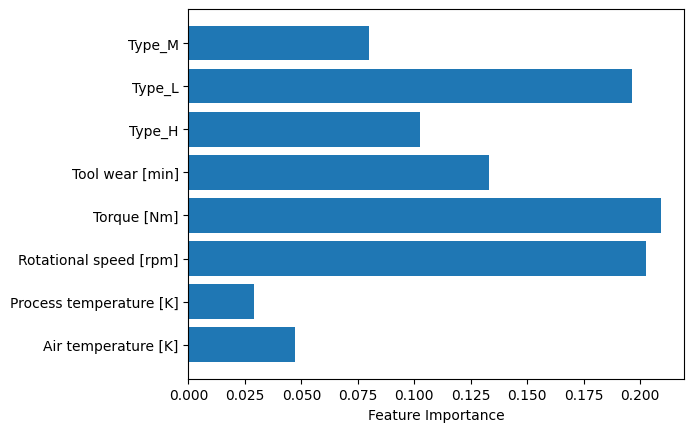

In [ ]:
import matplotlib.pyplot as plt
importances = xgb_model.feature_importances_
features = x.columns
plt.figure()
plt.barh(features,importances)
plt.xlabel('Feature Importance')
plt.show()


In [ ]:
def predict_failure(air_temp,process_temp,rpm,torque,tool_wear,type_H,type_L,type_M):
  import numpy as np
  input_data = np.array([[air_temp,process_temp,rpm,torque,tool_wear,type_H,type_L,type_M]])
  input_scaled = scaler.transform(input_data)
  prob = xgb_model.predict_proba(input_scaled)[0][1]
  threshold = 0.30
  prediction =1 if prob>threshold else 0
  return {
      "Failure probablity":round(float(prob),3),
      "Prediction": "FAIL" if prediction
      == 1 else "PASS"
  }

In [ ]:
predict_failure(air_temp =305,process_temp=315,rpm=1200,torque=70,tool_wear=220,type_H =0,type_L=1,type_M=0)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'Failure probablity': 0.999, 'Prediction': 'FAIL'}